In [38]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import pandas as pd

print("librosa version:", librosa.__version__)

librosa version: 0.11.0


## 1. Load an audio file

`librosa.load` returns a 1-D NumPy array of samples `y` and the sample rate `sr`.
By default librosa resamples to 22,050 Hz and mixes down to mono — pass `sr=None`
to keep the file's native sample rate.

In [6]:
# Path is relative to the repo root. The Emotions/ folder is gitignored,
# so make sure you have the dataset locally.
audio_path = "../Emotions/Angry/03-01-05-01-01-01-01.wav"

y, sr = librosa.load(audio_path) #load can only handle 1 track at time, need loop to organize the files

print(f"Samples shape : {y.shape}") #Shape iis how many sanpshots- SampleRate*Duration 
print(f"Sample rate   : {sr} Hz") # Sound is stored as snapshots/sec for computer, the default is 22050(/sec)
print(f"Duration      : {librosa.get_duration(y=y, sr=sr):.2f} s")

# Listen to it inline
Audio(data=y, rate=sr)

/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Samples shape : (85346,)
Sample rate   : 22050 Hz
Duration      : 3.87 s


## 2. Waveform (amplitude over time)

The raw signal. Angry speech tends to be loud with sharp, high-energy bursts.

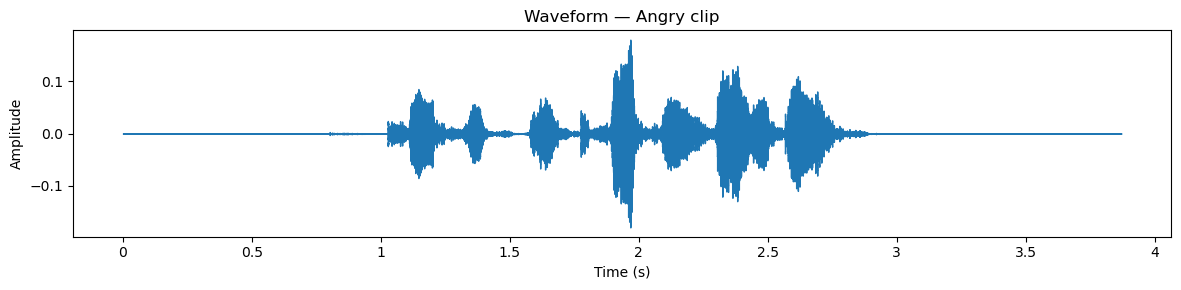

In [7]:
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform — Angry clip")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude") #this is the relvative loudness to the track, each track has its fitted value. 
plt.tight_layout()
plt.show()

## 3. Spectrogram (STFT)

A spectrogram shows how the frequency content changes over time. We take the
Short-Time Fourier Transform and convert amplitude to decibels for visualization.

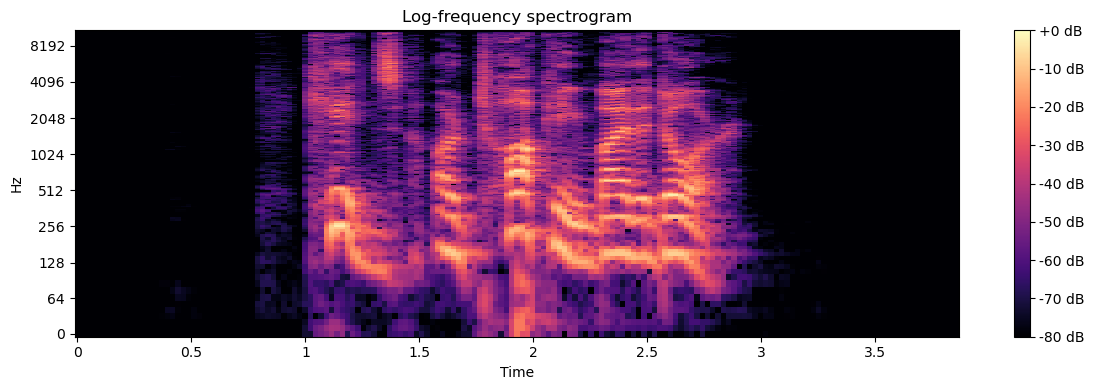

In [8]:
D = librosa.stft(y)            # complex ShortTermFourierTransform
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(img, format="%+2.0f dB")
plt.title("Log-frequency spectrogram")
plt.tight_layout()
plt.show()

#Spectrogram shows the energy(dB) of each frenquency(wave) at given time

## 4. MFCCs (Mel-Frequency Cepstral Coefficients)

MFCCs are a compact summary of the spectral envelope and a classic feature for
speech-emotion recognition. Here we extract 13 coefficients per frame.

In [39]:
mfccs = librosa.feature.mfcc(y=y, sr=sr) #n_mfcc default 20
print("MFCC shape (n_mfcc, frames):", mfccs.shape)
mfcc_df = pd.DataFrame(mfccs)          # rows = 20 coefficients, cols = 126 frames
print(mfcc_df.shape)                   # (20, 126)
mfcc_df   

MFCC shape (n_mfcc, frames): (20, 167)
(20, 167)


,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,...,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385,-732.119385
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


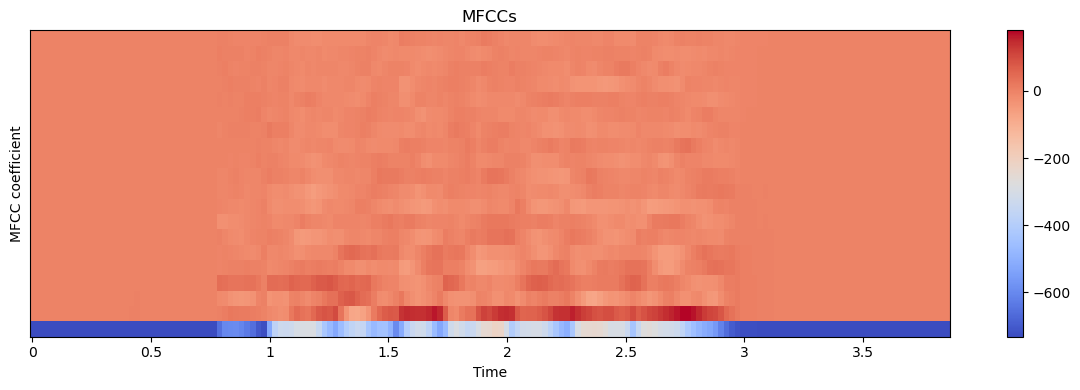

In [36]:
plt.figure(figsize=(12, 4))
img = librosa.display.specshow(mfccs, sr=sr, x_axis="time")
plt.colorbar(img)
plt.title("MFCCs")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.show()

## 5. A**Zero-crossing rate**

- **Zero-crossing rate** — how often the signal changes sign (noisiness / percussiveness).


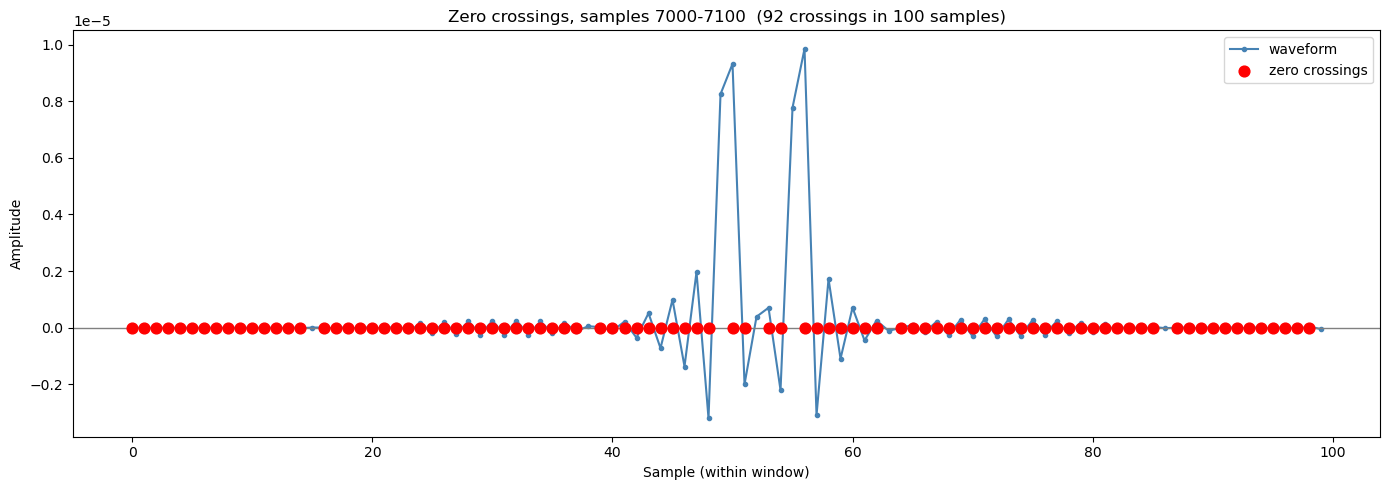

In [13]:
# Plot a short interval of the real sample and mark every zero crossing.
n0, n1 = 7000, 7100          # 100-sample window — adjust to zoom in/out
seg = y[n0:n1]

# indices (within the window) where the sign flips = zero crossings
crossings = np.where(np.diff(np.sign(seg)))[0]

plt.figure(figsize=(14, 5))
plt.plot(seg, marker="o", ms=3, color="steelblue", label="waveform")
plt.axhline(0, color="gray", lw=1)                         # the "0" line
plt.scatter(crossings, np.zeros_like(crossings), color="red",
            s=60, zorder=3, label="zero crossings")
plt.title(f"Zero crossings, samples {n0}-{n1}  "
          f"({len(crossings)} crossings in {n1 - n0} samples)")
plt.xlabel("Sample (within window)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
zc = librosa.zero_crossings(y)     # shape (85346,) — one bool per sample
print(zc[:5])     
print(zc.sum()) 

[ True False False False False]
28685


(1, 167)
[0.12255859 0.17480469 0.17480469 0.17480469 0.05175781]


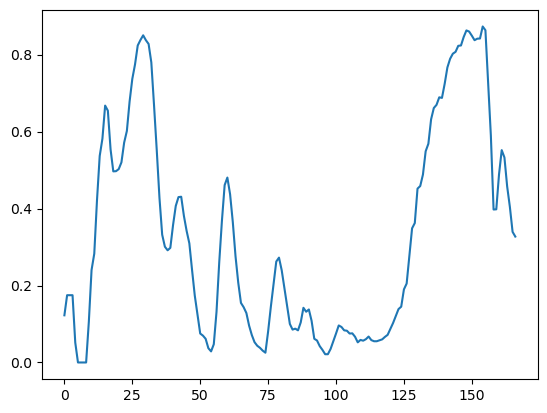

In [ ]:
zcrs=librosa.feature.zero_crossing_rate(y) # the ZeroCrossingRate per frame
print(zcrs.shape) #n_frames = 1 + (n_samples // hop_length)
print(zcrs[0][:5])   
plt.plot(zcrs[0])

## 6. Spectral centroid


-  the "center of mass" of the spectrum (perceived brightness).
- centroid = Σ(frequency × magnitude) / Σ(magnitude)
So it's a weighted mean across all bins, not the max of one bin.



In [31]:
SpectralCentroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]   # ✅
SpectralCentroid.shape    # (167,)


(167,)

Text(0.5, 0, 'Time (s)')

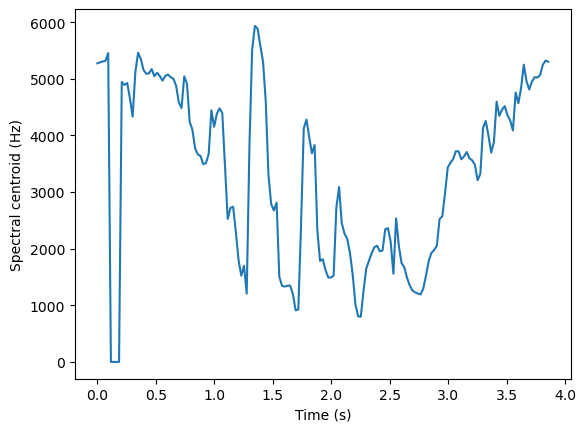

In [32]:
t = librosa.frames_to_time(range(len(SpectralCentroid)), sr=sr)
plt.plot(t, SpectralCentroid)
plt.ylabel("Spectral centroid (Hz)")
plt.xlabel("Time (s)")


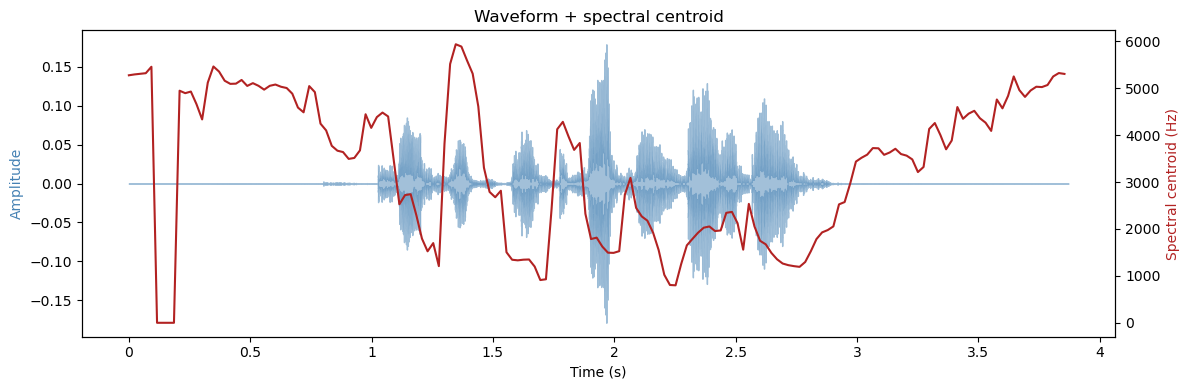

In [34]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# waveform on the left axis
librosa.display.waveshow(y, sr=sr, ax=ax1, alpha=0.5, color="steelblue")
ax1.set_ylabel("Amplitude", color="steelblue")
ax1.set_xlabel("Time (s)")

# centroid on a second axis sharing the same x (time)
ax2 = ax1.twinx()
ax2.plot(t, SpectralCentroid, color="firebrick", label="Spectral centroid")
ax2.set_ylabel("Spectral centroid (Hz)", color="firebrick")

plt.title("Waveform + spectral centroid")
plt.tight_layout()
plt.show()


## Chroma Feature


-  12-element feature vector indicating how much energy of each pitch class is present 
-  C, C#, D, D#, E, F, F#, G, G#, A, A#, B.



(12, 167)


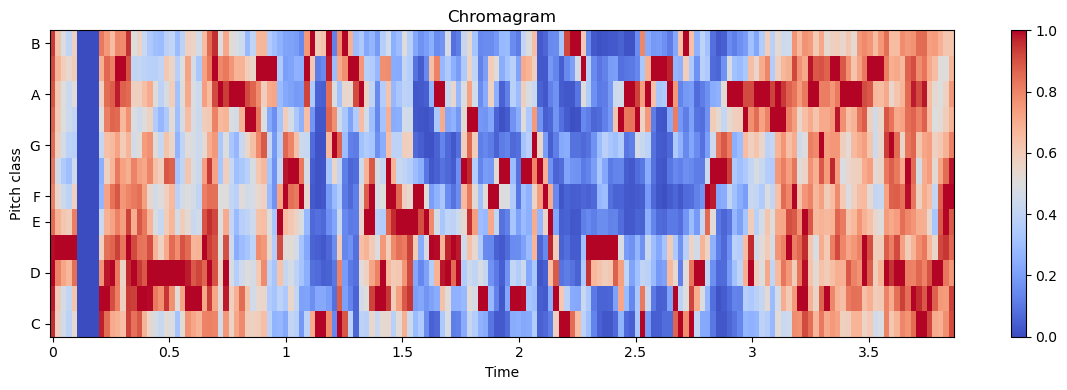

In [42]:
chromagram = librosa.feature.chroma_stft(y=y, sr=sr)
print(chromagram.shape)     # (12, n_frames)

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(chromagram, sr=sr,
                               x_axis="time", y_axis="chroma", cmap="coolwarm")
plt.colorbar(img)
plt.title("Chromagram")
plt.tight_layout()
plt.show()


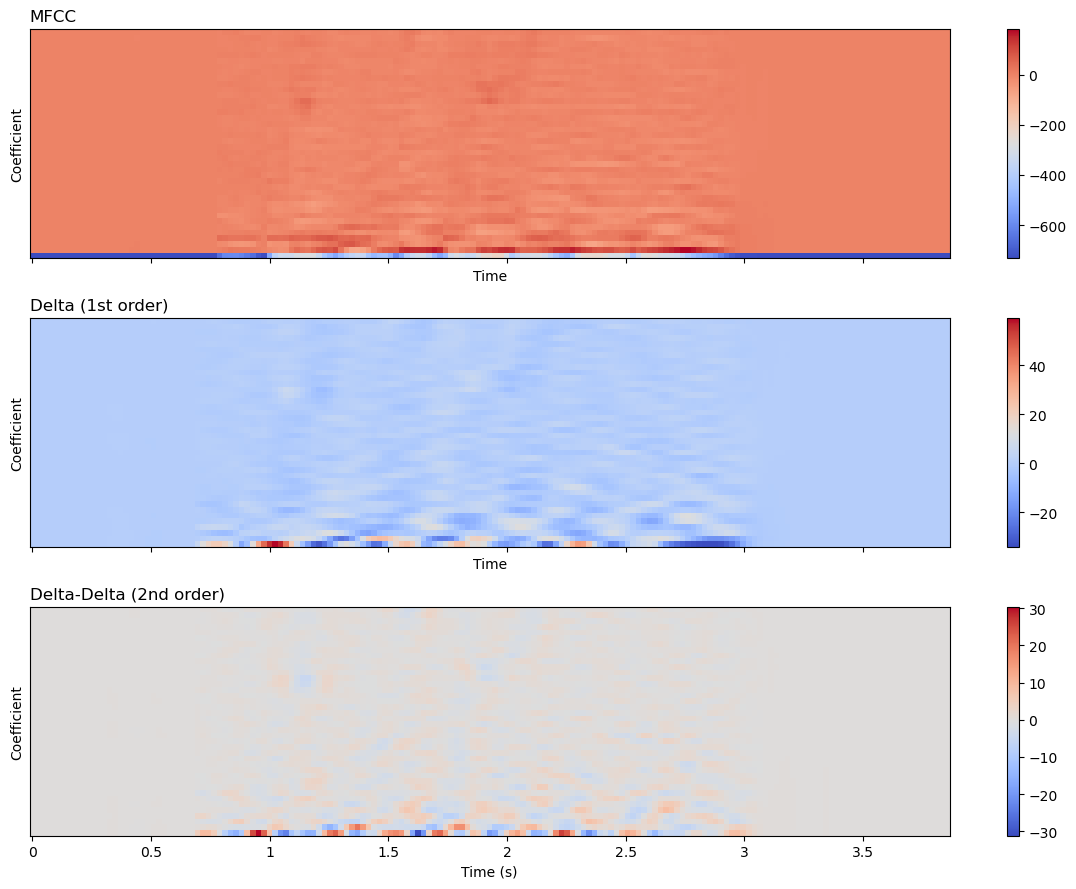

In [44]:
mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
delta  = librosa.feature.delta(mfcc)
delta2 = librosa.feature.delta(mfcc, order=2)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, data, title in zip(
        axes,
        [mfcc, delta, delta2],
        ["MFCC", "Delta (1st order)", "Delta-Delta (2nd order)"]):
    img = librosa.display.specshow(data, sr=sr, x_axis="time", ax=ax)
    ax.set_title(title, loc="left")
    ax.set_ylabel("Coefficient")
    fig.colorbar(img, ax=ax)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


In [45]:
f0, voiced_flag, voiced_prob = librosa.pyin(
    y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), sr=sr)


In [ ]:
pitches, magnitudes=librosa.piptrack(y=y,sr=sr)
print(pitches)
print(magnitudes)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


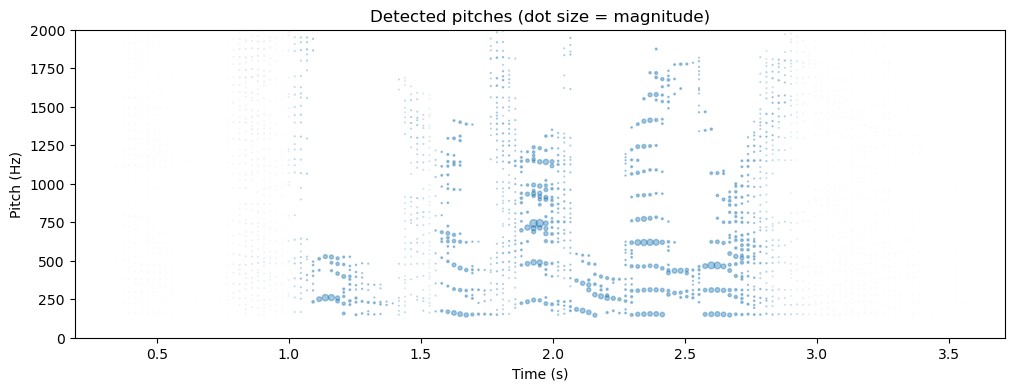

In [51]:
idx = magnitudes > np.median(magnitudes[magnitudes > 0])   # keep stronger ones
freqs = pitches[idx]
mags  = magnitudes[idx]
frame_idx = np.where(idx)[1]
t_scatter = librosa.frames_to_time(frame_idx, sr=sr)

plt.figure(figsize=(12, 4))
plt.scatter(t_scatter, freqs, s=mags / mags.max() * 30, alpha=0.4)
plt.ylim(0, 2000); plt.xlabel("Time (s)"); plt.ylabel("Pitch (Hz)")
plt.title("Detected pitches (dot size = magnitude)")
plt.show()
